# Aerogel Filtration ML --> Step 5: SHAP Feature Importance

**What this notebook does:**
- Computes SHAP values for XGBoost (filtration efficiency) and RF (quality factor)
- Produces global importance rankings (beeswarm + bar plots)
- Plots dependence plots for top 5 features per target
- Computes SHAP interaction values to find synergistic feature pairs
- Builds a consensus importance ranking across both models


## 5.1: Install and import

In [1]:
!pip install shap matplotlib seaborn pandas numpy --quiet

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('SHAP version:', shap.__version__)
print('Libraries loaded.')

SHAP version: 0.48.0
Libraries loaded.


## 5.2: Load models and data from Step 4

In [2]:
# Load everything saved by Step 4
with open('step4_models.pkl', 'rb') as f:
    saved = pickle.load(f)

final_rf_eff  = saved['final_rf_eff']   # RF fitted on full filtration data
final_xgb_eff = saved['final_xgb_eff']  # XGBoost fitted on full filtration data
final_rf_qf   = saved['final_rf_qf']    # RF fitted on full QF data
final_xgb_qf  = saved['final_xgb_qf']  # XGBoost fitted on full QF data
FEATURES_EFF  = saved['FEATURES_EFF']
FEATURES_QF   = saved['FEATURES_QF']
X_eff_full    = saved['X_eff_full']     # imputed feature matrix, filtration
X_qf_full     = saved['X_qf_full']      # imputed feature matrix, QF

# use DataFrames so SHAP plots show feature names

X_eff_df = pd.DataFrame(X_eff_full, columns=FEATURES_EFF)
X_qf_df  = pd.DataFrame(X_qf_full,  columns=FEATURES_QF)

print('Loaded:')
print(f'  Filtration efficiency: {X_eff_df.shape[0]} samples, {X_eff_df.shape[1]} features')
print(f'  Quality factor:        {X_qf_df.shape[0]} samples, {X_qf_df.shape[1]} features')

Loaded:
  Filtration efficiency: 195 samples, 57 features
  Quality factor:        82 samples, 57 features


## 5.3: Clean feature names for plots

In [3]:

def clean_name(name):
    name = name.replace('log_', '')
    name = name.replace('_', ' ')
    name = name.replace('(', '(').replace(')', ')')
    # Capitalise first letter only
    return name[0].upper() + name[1:]

feature_names_eff = [clean_name(f) for f in FEATURES_EFF]
feature_names_qf  = [clean_name(f) for f in FEATURES_QF]

# Apply clean names to DataFrames

X_eff_df.columns = feature_names_eff
X_qf_df.columns  = feature_names_qf

print('Sample clean feature names:')
for raw, clean in zip(FEATURES_EFF[:8], feature_names_eff[:8]):
    print(f'  {raw:<45} -> {clean}')

Sample clean feature names:
  solid_content (g/100ml)                       -> Solid content (g/100ml)
  log_skeletal_density (g/cm3)                  -> Skeletal density (g/cm3)
  log_porosity (%)                              -> Porosity (%)
  log_permeability (m2)                         -> Permeability (m2)
  bet_surface_area (m2/g)                       -> Bet surface area (m2/g)
  log_average_pore_size (nm)                    -> Average pore size (nm)
  log_fiber_diameter (nm)                       -> Fiber diameter (nm)
  log_airflow_rate (cm/s)                       -> Airflow rate (cm/s)


## 5.4: Compute SHAP values

In [4]:
# We compute SHAP values for:
#   - XGBoost on filtration efficiency (primary model)
#   - RF on filtration efficiency (robustness check)
#   - XGBoost on quality factor (primary model)       
#   - RF on quality factor (robustness check)          

print('Computing SHAP values — XGBoost (filtration efficiency)...')
explainer_xgb_eff = shap.TreeExplainer(final_xgb_eff)
shap_xgb_eff = explainer_xgb_eff.shap_values(X_eff_df)
print(f'  Done. Shape: {shap_xgb_eff.shape}')

print('Computing SHAP values — RF (filtration efficiency)...')
explainer_rf_eff = shap.TreeExplainer(final_rf_eff)
shap_rf_eff = explainer_rf_eff.shap_values(X_eff_df)
print(f'  Done. Shape: {shap_rf_eff.shape}')

print('Computing SHAP values — XGBoost (quality factor, PRIMARY)...')
explainer_xgb_qf = shap.TreeExplainer(final_xgb_qf)
shap_xgb_qf = explainer_xgb_qf.shap_values(X_qf_df)
print(f'  Done. Shape: {shap_xgb_qf.shape}')

print('Computing SHAP values — RF (quality factor, robustness check)...')
explainer_rf_qf = shap.TreeExplainer(final_rf_qf)
shap_rf_qf = explainer_rf_qf.shap_values(X_qf_df)
print(f'  Done. Shape: {shap_xgb_qf.shape}')

print('\nAll SHAP values computed.')

Computing SHAP values — XGBoost (filtration efficiency)...
  Done. Shape: (195, 57)
Computing SHAP values — RF (filtration efficiency)...
  Done. Shape: (195, 57)
Computing SHAP values — XGBoost (quality factor, PRIMARY)...
  Done. Shape: (82, 57)
Computing SHAP values — RF (quality factor, robustness check)...
  Done. Shape: (82, 57)

All SHAP values computed.


## 5.5: Global importance: beeswarm plots

Saved: shap_beeswarm_filtration.png
Saved: shap_beeswarm_qualityfactor.png
Saved: shap_beeswarm_qualityfactor_rf_supp.png


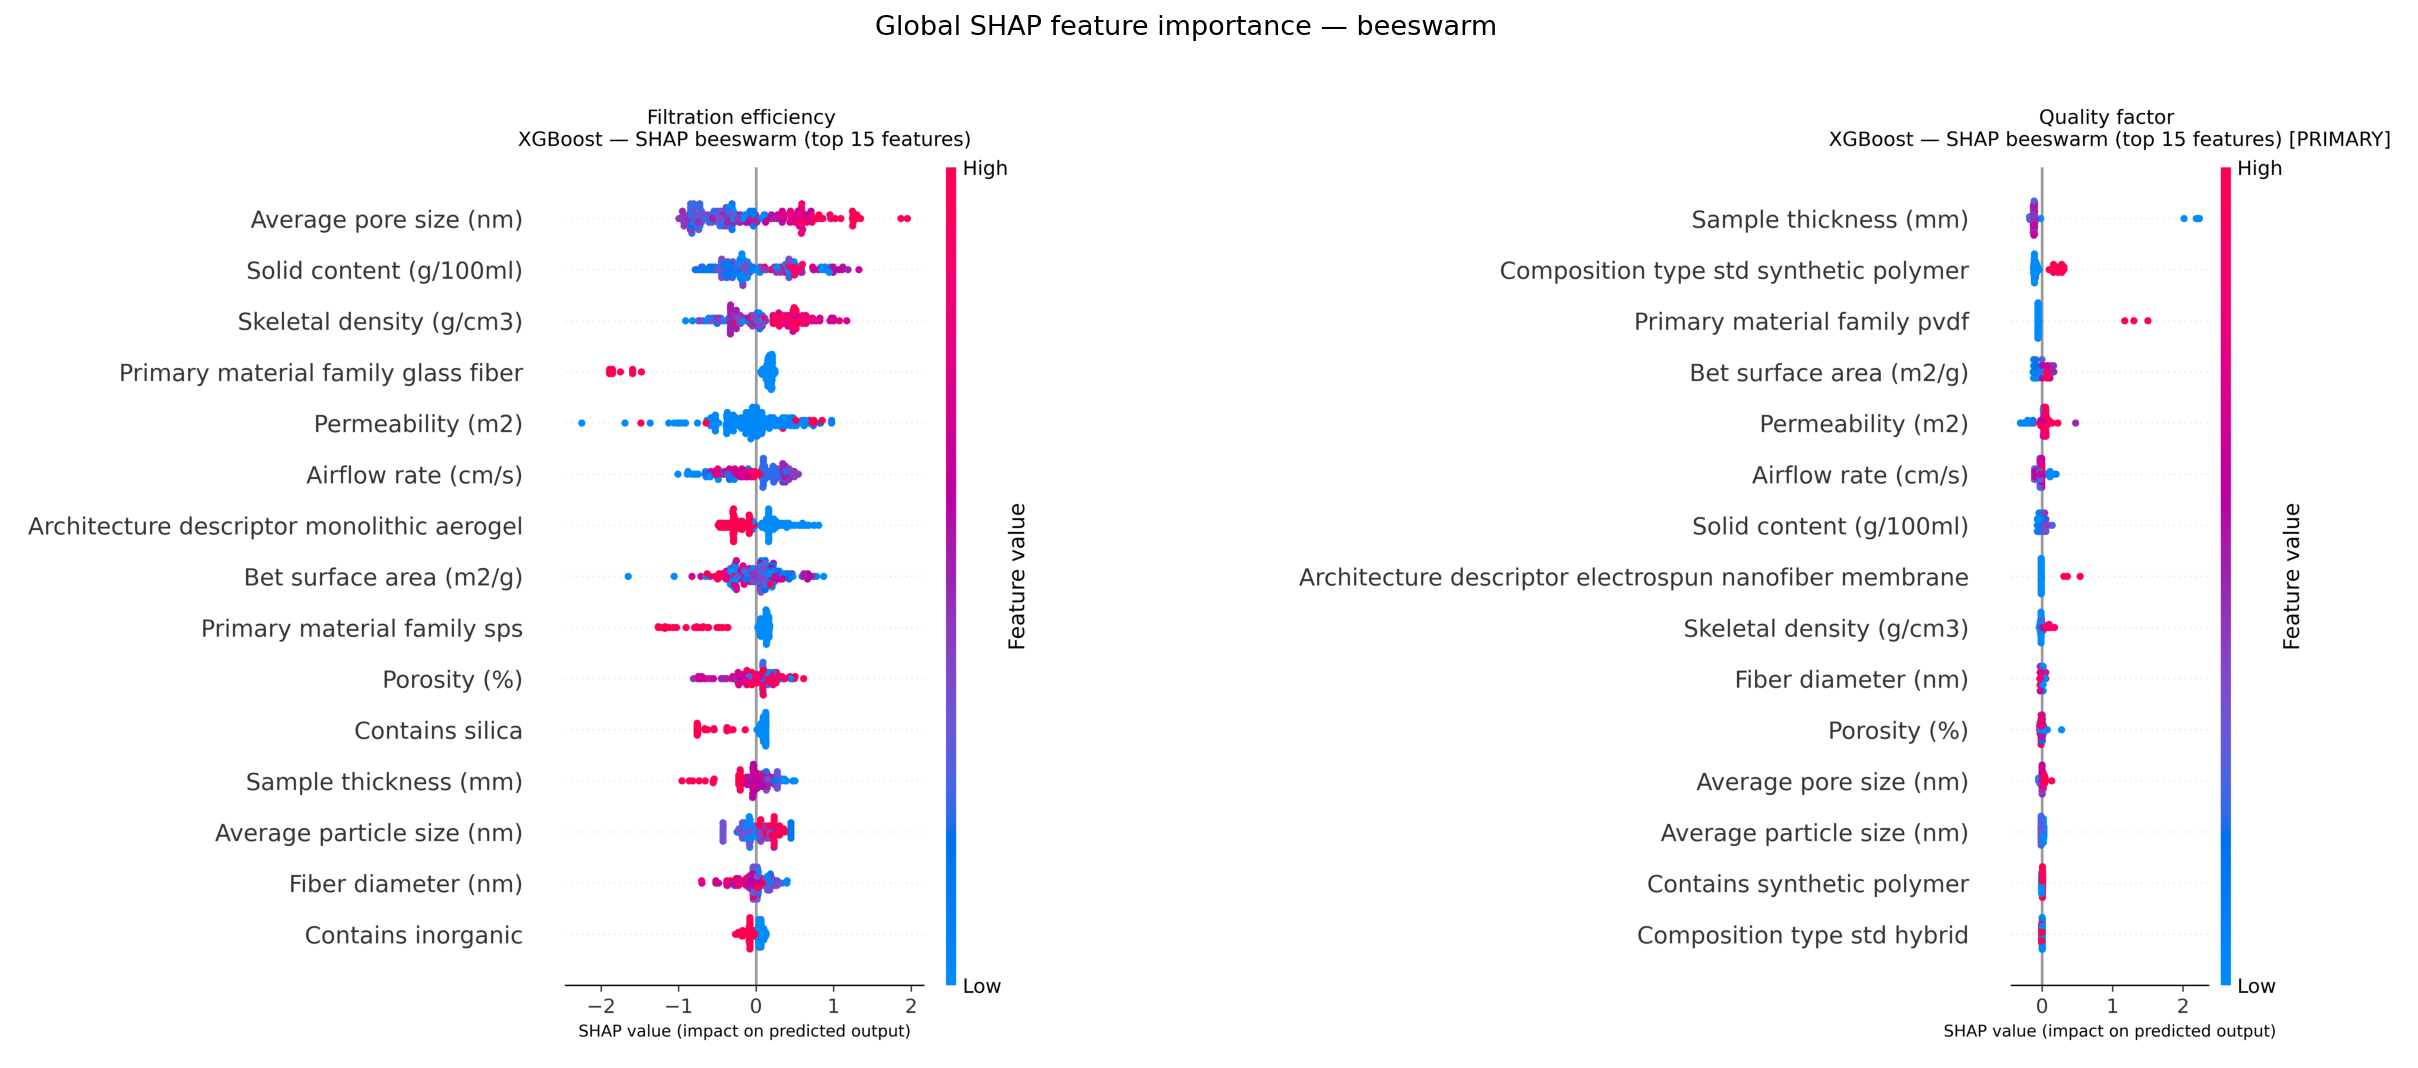

Saved: shap_beeswarm_combined.png


In [5]:

import matplotlib.image as mpimg

def save_shap_beeswarm(shap_values, X_df, title, filename, max_display=15):
    plt.figure(figsize=(9, 7))
    shap.summary_plot(
        shap_values, X_df,
        plot_type='dot',
        max_display=max_display,
        show=False,
        color_bar=True
    )
    plt.title(title, fontsize=11, pad=12)
    plt.xlabel('SHAP value (impact on predicted output)', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=600)
    plt.close()
    print(f'Saved: {filename}')

save_shap_beeswarm(
    shap_xgb_eff, X_eff_df,
    'Filtration efficiency \nXGBoost — SHAP beeswarm (top 15 features)',
    'shap_beeswarm_filtration.png'
)

save_shap_beeswarm(
    shap_xgb_qf, X_qf_df,
    'Quality factor \nXGBoost — SHAP beeswarm (top 15 features) [PRIMARY]',
    'shap_beeswarm_qualityfactor.png'
)

# Robustness-check version for supplementary material
save_shap_beeswarm(
    shap_rf_qf, X_qf_df,
    'Quality factor \nRandom Forest — SHAP beeswarm [supplementary]',
    'shap_beeswarm_qualityfactor_rf_supp.png'
)

# Combine side by side into one figure

img1 = mpimg.imread('shap_beeswarm_filtration.png')
img2 = mpimg.imread('shap_beeswarm_qualityfactor.png')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(img1); axes[0].axis('off')
axes[1].imshow(img2); axes[1].axis('off')
plt.suptitle('Global SHAP feature importance — beeswarm', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_beeswarm_combined.png', bbox_inches='tight', dpi=600)
plt.show()
print('Saved: shap_beeswarm_combined.png')

## 5.6: Global importance: bar plots (mean |SHAP|)

Saved: shap_bar_filtration.png
Saved: shap_bar_qualityfactor.png


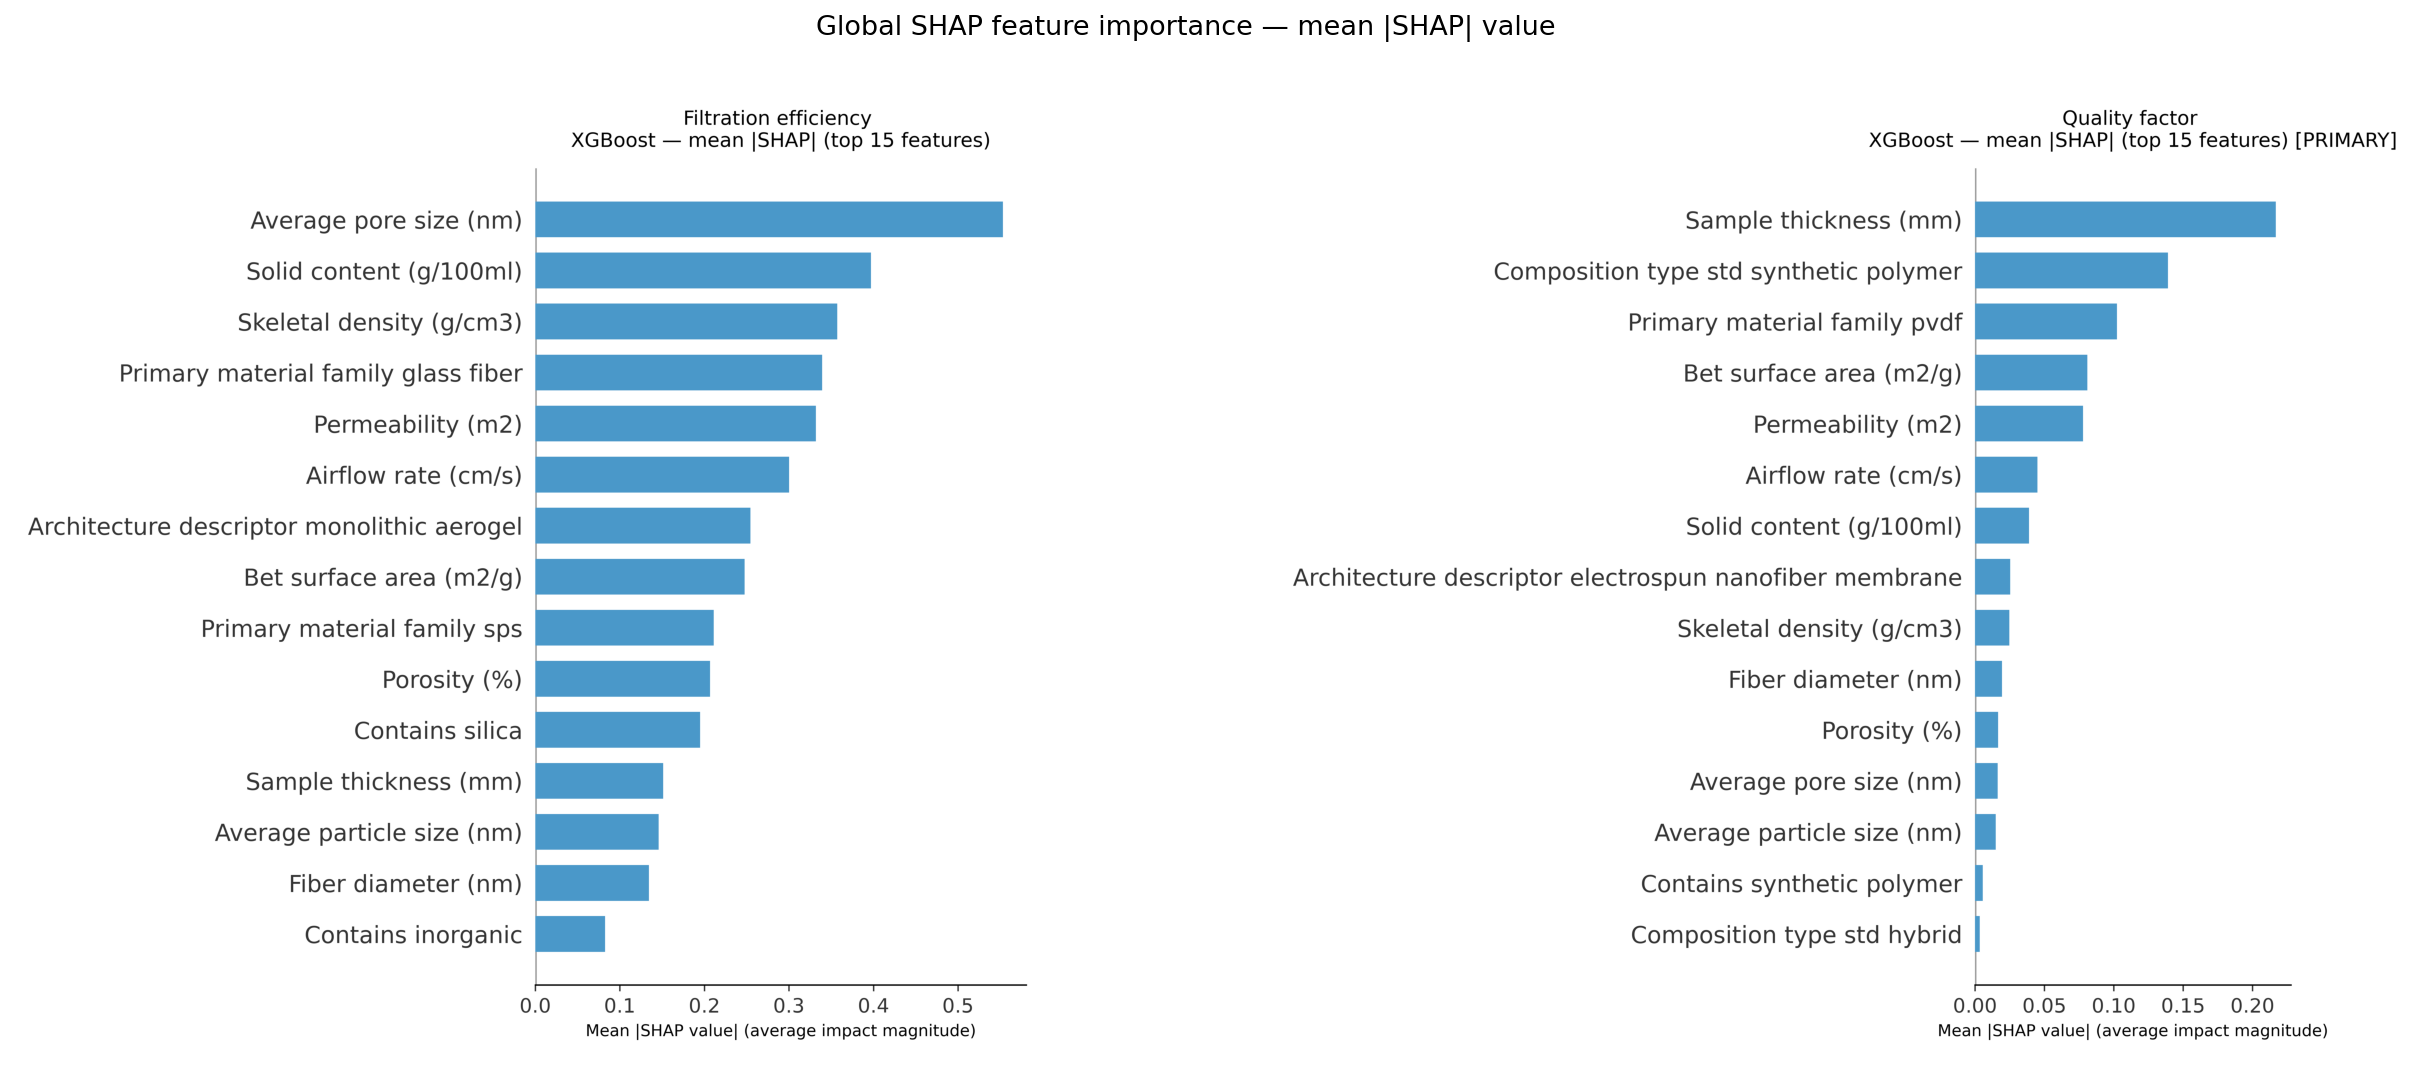

Saved: shap_bar_combined.png


In [6]:

def save_shap_bar(shap_values, X_df, title, filename, max_display=15):
    plt.figure(figsize=(9, 7))
    shap.summary_plot(
        shap_values, X_df,
        plot_type='bar',
        max_display=max_display,
        show=False,
        color=plt.get_cmap('Blues')(0.6)
    )
    plt.title(title, fontsize=11, pad=12)
    plt.xlabel('Mean |SHAP value| (average impact magnitude)', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=600)
    plt.close()
    print(f'Saved: {filename}')

save_shap_bar(
    shap_xgb_eff, X_eff_df,
    'Filtration efficiency \nXGBoost — mean |SHAP| (top 15 features)',
    'shap_bar_filtration.png'
)

save_shap_bar(
    shap_xgb_qf, X_qf_df,
    'Quality factor \nXGBoost — mean |SHAP| (top 15 features) [PRIMARY]',
    'shap_bar_qualityfactor.png'
)

import matplotlib.image as mpimg
img1 = mpimg.imread('shap_bar_filtration.png')
img2 = mpimg.imread('shap_bar_qualityfactor.png')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(img1); axes[0].axis('off')
axes[1].imshow(img2); axes[1].axis('off')
plt.suptitle('Global SHAP feature importance — mean |SHAP| value', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_bar_combined.png', bbox_inches='tight', dpi=600)
plt.show()
print('Saved: shap_bar_combined.png')

## 5.7: Extract and print importance rankings

In [7]:
# Extract the numerical SHAP importance values for all features.

def shap_importance_df(shap_values, feature_names, model_name):
    """Return a DataFrame of features ranked by mean |SHAP|."""
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    df = pd.DataFrame({
        'Feature':     feature_names,
        'Mean |SHAP|': mean_abs_shap,
        'Model':       model_name
    }).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
    df['Rank'] = df.index + 1
    return df

imp_xgb_eff = shap_importance_df(shap_xgb_eff, feature_names_eff, 'XGBoost (filtration eff.)')
imp_rf_eff  = shap_importance_df(shap_rf_eff,  feature_names_eff, 'RF (filtration eff.)')
imp_rf_qf   = shap_importance_df(shap_rf_qf,   feature_names_qf,  'RF (quality factor)')
imp_xgb_qf  = shap_importance_df(shap_xgb_qf,  feature_names_qf,  'XGBoost (quality factor)')

print('TOP 15 FEATURES — XGBoost (Filtration efficiency)')
print(imp_xgb_eff[['Rank', 'Feature', 'Mean |SHAP|']].head(15).to_string(index=False))

print('\nTOP 15 FEATURES — XGBoost (Quality factor, PRIMARY)')
print(imp_xgb_qf[['Rank', 'Feature', 'Mean |SHAP|']].head(15).to_string(index=False))

print('\nTOP 15 FEATURES — RF (Quality factor, robustness check)')
print(imp_rf_qf[['Rank', 'Feature', 'Mean |SHAP|']].head(15).to_string(index=False))

pd.concat([imp_xgb_eff, imp_rf_eff, imp_rf_qf, imp_xgb_qf]).to_csv(
    'shap_importance_all.csv', index=False
)
print('\nSaved: shap_importance_all.csv')

TOP 15 FEATURES — XGBoost (Filtration efficiency)
 Rank                                    Feature  Mean |SHAP|
    1                     Average pore size (nm)     0.552983
    2                    Solid content (g/100ml)     0.396968
    3                   Skeletal density (g/cm3)     0.357171
    4        Primary material family glass fiber     0.339216
    5                          Permeability (m2)     0.331855
    6                        Airflow rate (cm/s)     0.300215
    7 Architecture descriptor monolithic aerogel     0.254575
    8                    Bet surface area (m2/g)     0.247484
    9                Primary material family sps     0.211055
   10                               Porosity (%)     0.206677
   11                            Contains silica     0.194901
   12                      Sample thickness (mm)     0.151148
   13                 Average particle size (nm)     0.145941
   14                        Fiber diameter (nm)     0.134295
   15               

## 5.8: Dependence plots: top 5 features per target

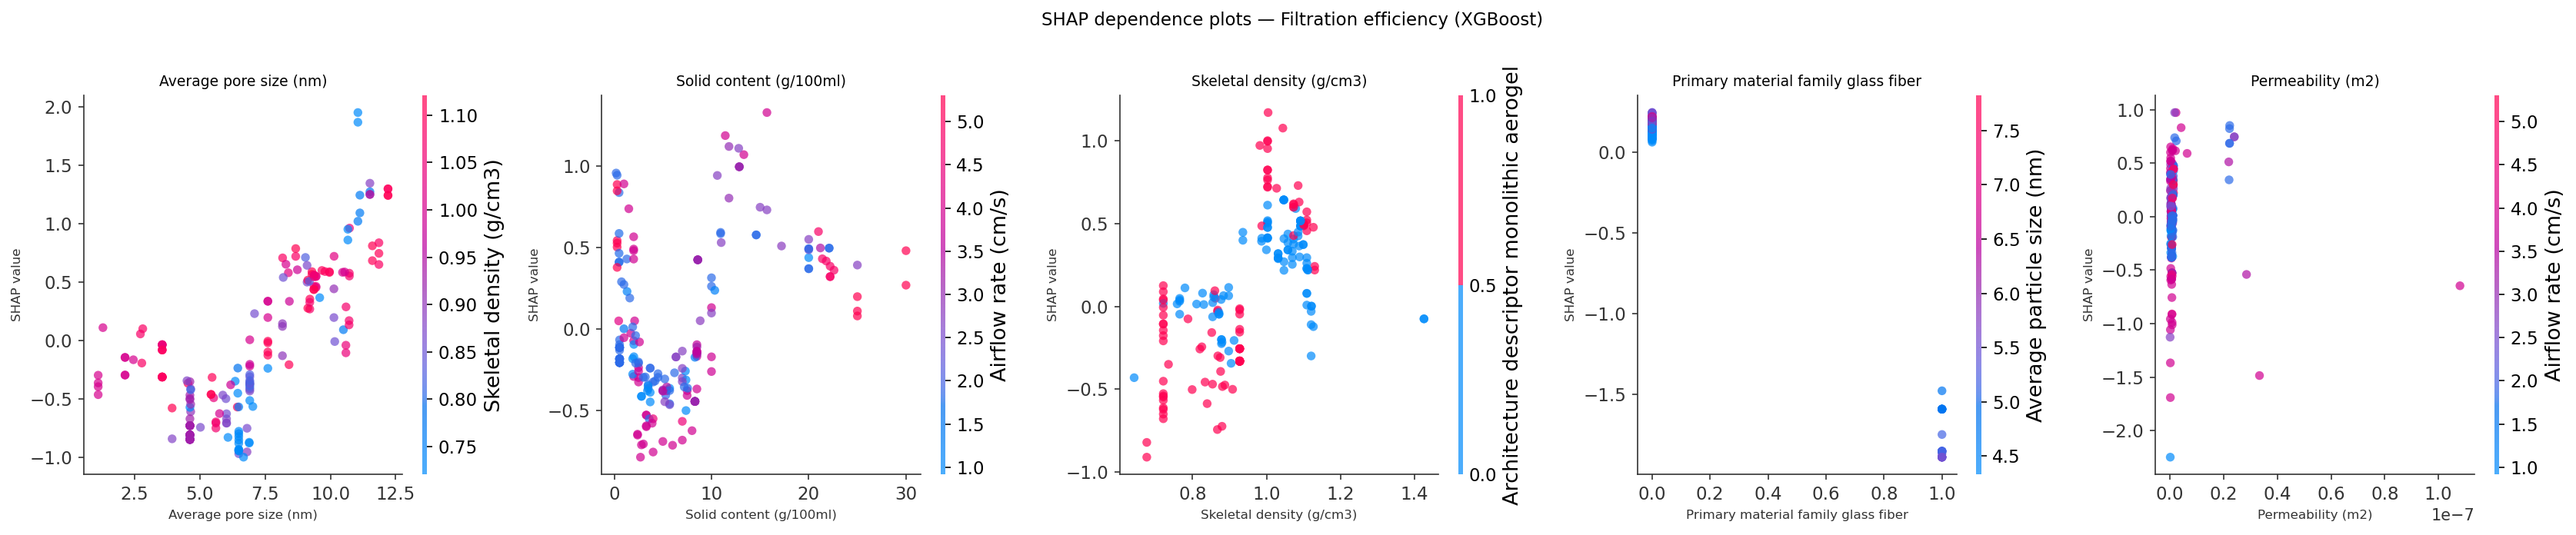

Saved: shap_dependence_filtration.png


In [8]:
# Dependence plots show:
#   x-axis: actual feature value
#   y-axis: SHAP value (how much this feature pushed the prediction up or down)
#   colour: the feature that most strongly interacts with x
#           (chosen automatically by SHAP)

def plot_dependence_grid(shap_values, X_df, imp_df, title, filename, top_n=5):
    top_features = imp_df['Feature'].head(top_n).tolist()
    fig, axes = plt.subplots(1, top_n, figsize=(4.5 * top_n, 4.5))
    if top_n == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_features):
        if feat not in X_df.columns:
            continue
        feat_idx = list(X_df.columns).index(feat)
        shap.dependence_plot(
            feat_idx,
            shap_values,
            X_df,
            ax=ax,
            show=False,
            dot_size=30,
            alpha=0.7
        )
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel('SHAP value', fontsize=8)

    plt.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


# Filtration efficiency --> top 5 features
plot_dependence_grid(
    shap_xgb_eff, X_eff_df, imp_xgb_eff,
    title='SHAP dependence plots — Filtration efficiency (XGBoost)',
    filename='shap_dependence_filtration.png',
    top_n=5
)

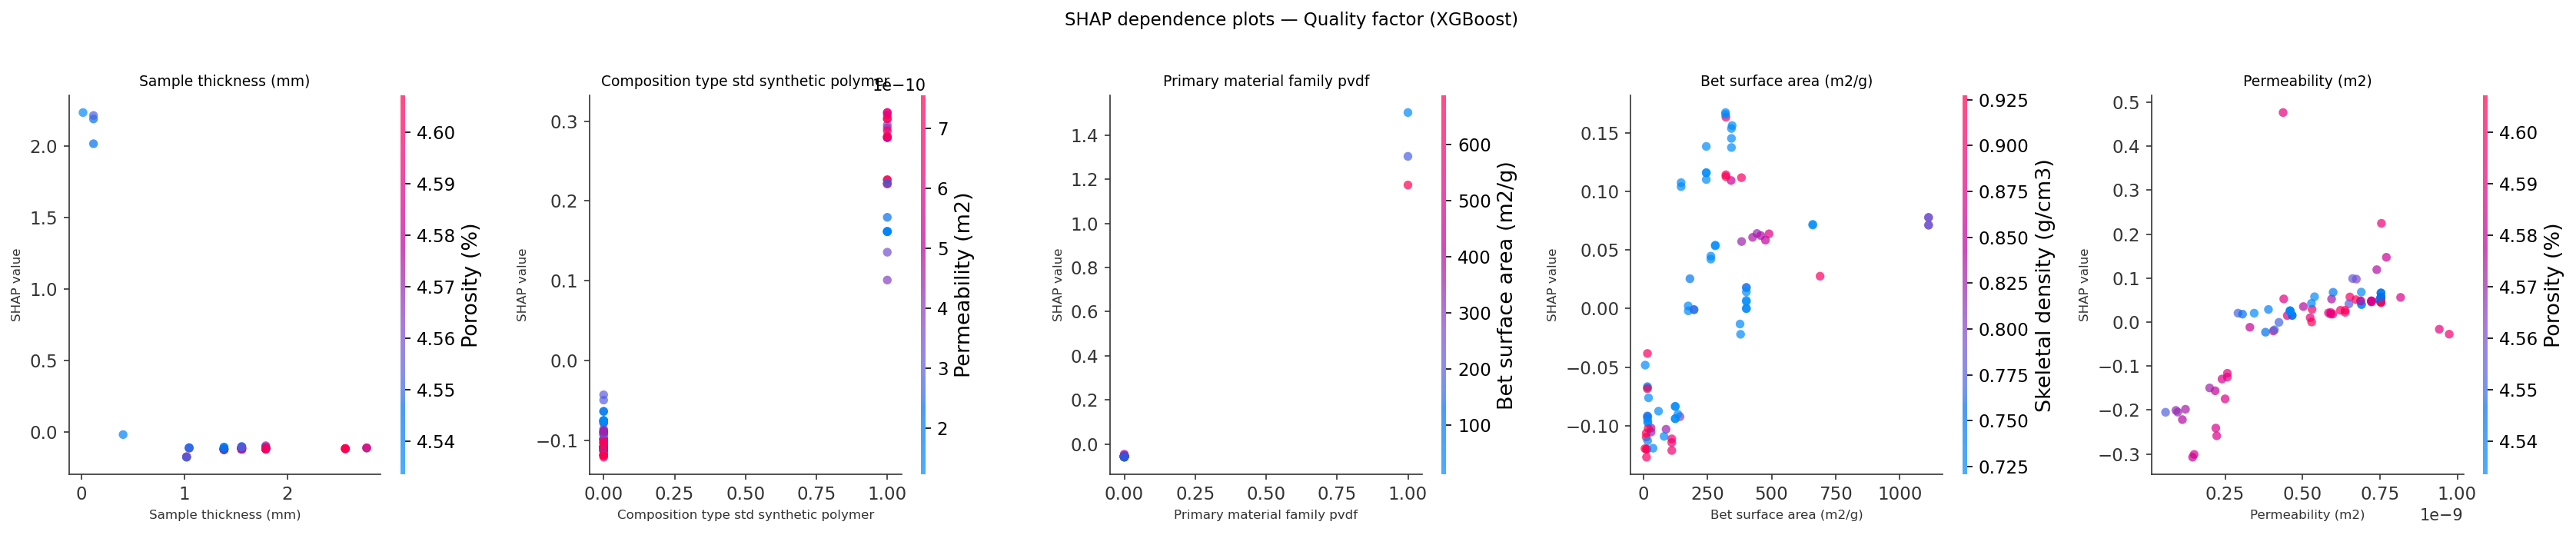

Saved: shap_dependence_qualityfactor.png


In [9]:
# Quality factor --> top 5 features
plot_dependence_grid(
    shap_xgb_qf, X_qf_df, imp_xgb_qf,        # ← should use XGBoost (primarymodel)
    title='SHAP dependence plots — Quality factor (XGBoost)',
    filename='shap_dependence_qualityfactor.png',
    top_n=5
)

## 5.9: SHAP interaction values (top feature pairs)

In [11]:

shap_interaction_eff = explainer_xgb_eff.shap_interaction_values(X_eff_df)
print(f'Done. Interaction matrix shape: {shap_interaction_eff.shape}')

# Shape is (n_samples, n_features, n_features)
# shap_interaction_eff[i, j, k] = interaction between feature j and k for sample i

Done. Interaction matrix shape: (195, 57, 57)


In [13]:
# Summarize interactions: mean absolute interaction across all samples
# Off-diagonal elements are the pairwise interactions
# Diagonal elements are the main effects

n_features = len(feature_names_eff)
mean_abs_interaction = np.abs(shap_interaction_eff).mean(axis=0)

# Build interaction DataFrame (off-diagonal only)
interaction_pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        interaction_pairs.append({
            'Feature A':     feature_names_eff[i],
            'Feature B':     feature_names_eff[j],
            
            'Interaction':   mean_abs_interaction[i, j] * 2
        })

interaction_df = pd.DataFrame(interaction_pairs).sort_values(
    'Interaction', ascending=False
).reset_index(drop=True)

print('TOP 15 FEATURE INTERACTIONS (XGBoost, filtration efficiency)')
print('=' * 65)
print(interaction_df.head(15).to_string(index=False))

interaction_df.to_csv('shap_interactions_filtration.csv', index=False)
print('\nSaved: shap_interactions_filtration.csv')

TOP 15 FEATURE INTERACTIONS (XGBoost, filtration efficiency)
               Feature A                                  Feature B  Interaction
Skeletal density (g/cm3) Architecture descriptor monolithic aerogel     0.246722
Skeletal density (g/cm3)                     Average pore size (nm)     0.122874
  Average pore size (nm) Architecture descriptor monolithic aerogel     0.118108
Skeletal density (g/cm3)                          Permeability (m2)     0.097403
 Solid content (g/100ml)                     Average pore size (nm)     0.096797
 Solid content (g/100ml)                Primary material family sps     0.089799
Skeletal density (g/cm3)                        Airflow rate (cm/s)     0.089739
  Average pore size (nm)                        Airflow rate (cm/s)     0.084227
Skeletal density (g/cm3)                               Porosity (%)     0.082061
       Permeability (m2)                        Airflow rate (cm/s)     0.079224
            Porosity (%)                     Ave

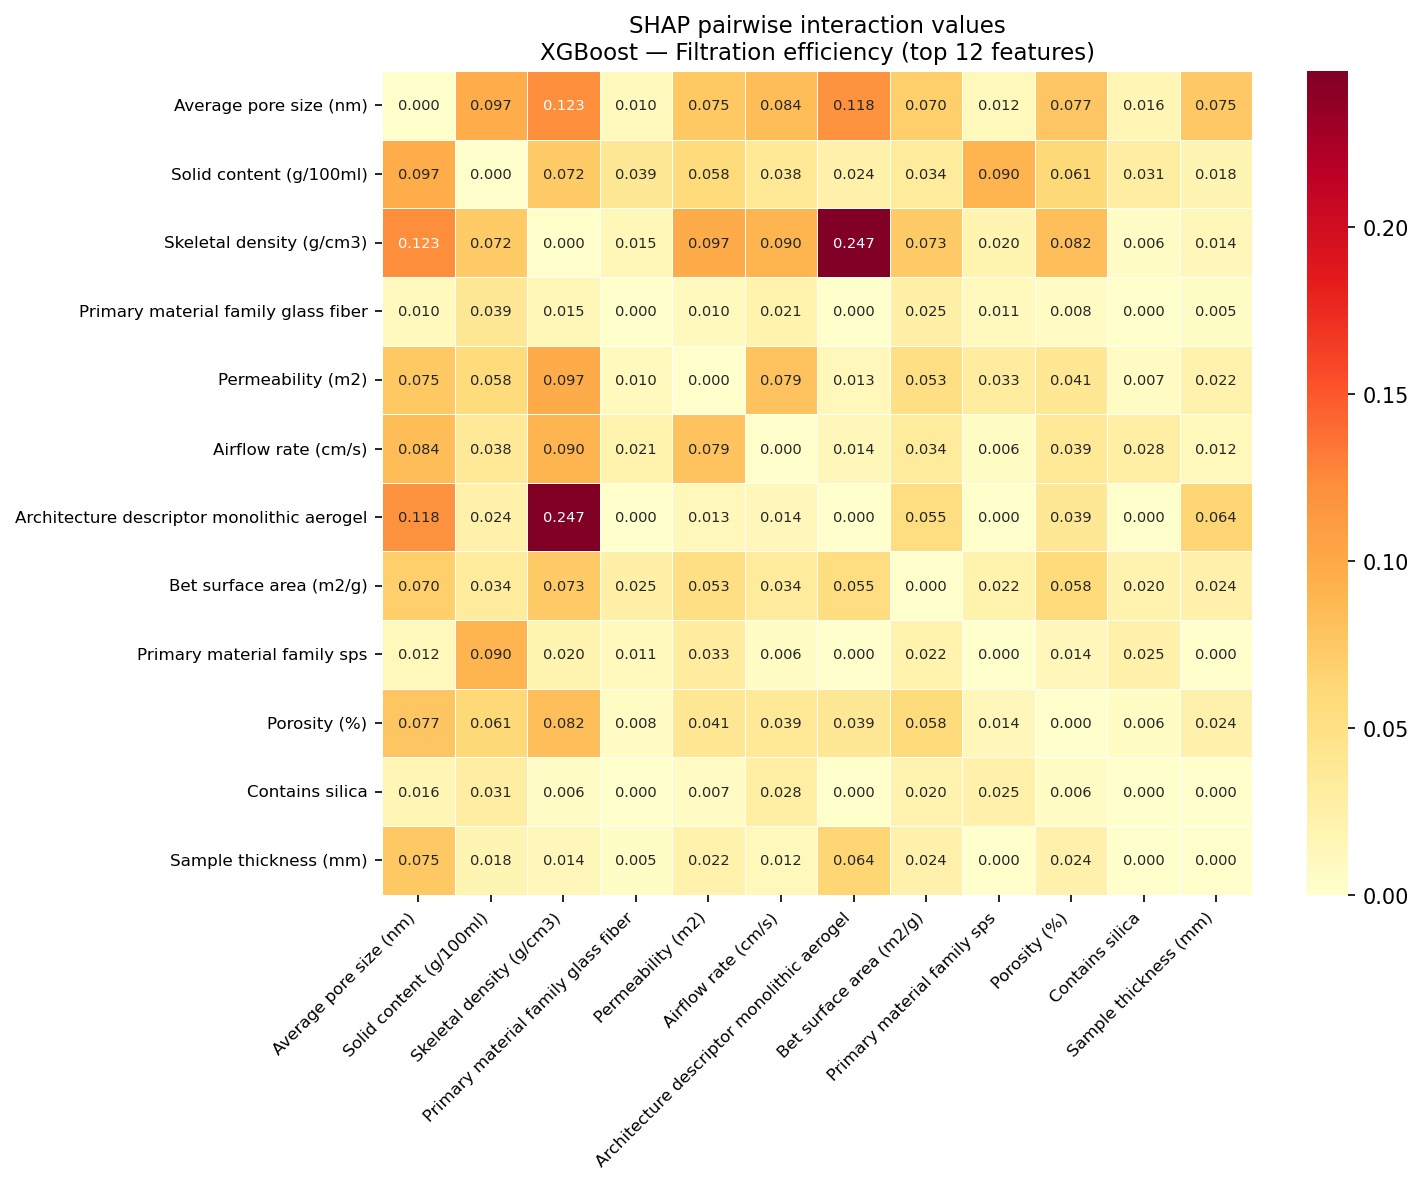

Saved: shap_interaction_heatmap.png


In [14]:
# Heatmap of the top pairwise interactions
# Restricts to top 12 features by main effect for readability

top12_features = imp_xgb_eff['Feature'].head(12).tolist()
top12_idx = [feature_names_eff.index(f) for f in top12_features
             if f in feature_names_eff]

interaction_matrix = mean_abs_interaction[np.ix_(top12_idx, top12_idx)] * 2
# Zero out diagonal (main effects) so colour scale focuses on interactions
np.fill_diagonal(interaction_matrix, 0)

top12_labels = [feature_names_eff[i] for i in top12_idx]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    interaction_matrix,
    xticklabels=top12_labels,
    yticklabels=top12_labels,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('SHAP pairwise interaction values\nXGBoost — Filtration efficiency (top 12 features)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('shap_interaction_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: shap_interaction_heatmap.png')

## 5.10: Consensus importance ranking across models

In [15]:

def borda_count(imp_dfs, feature_col='Feature'):
    """Combine importance rankings using Borda count."""
    all_features = imp_dfs[0][feature_col].tolist()
    n = len(all_features)
    scores = {f: 0 for f in all_features}

    for imp_df in imp_dfs:
        for rank, feat in enumerate(imp_df[feature_col]):
            if feat in scores:
                scores[feat] += (n - rank)  # higher rank = more points

    return pd.DataFrame([
        {'Feature': f, 'Borda score': s}
        for f, s in scores.items()
    ]).sort_values('Borda score', ascending=False).reset_index(drop=True)


# Consensus for filtration efficiency (XGBoost + RF)
consensus_eff = borda_count([imp_xgb_eff, imp_rf_eff])
consensus_eff['Consensus rank'] = consensus_eff.index + 1
consensus_eff['XGBoost rank'] = consensus_eff['Feature'].apply(
    lambda f: imp_xgb_eff[imp_xgb_eff['Feature']==f]['Rank'].values[0]
    if f in imp_xgb_eff['Feature'].values else 'N/A'
)
consensus_eff['RF rank'] = consensus_eff['Feature'].apply(
    lambda f: imp_rf_eff[imp_rf_eff['Feature']==f]['Rank'].values[0]
    if f in imp_rf_eff['Feature'].values else 'N/A'
)

# Consensus for quality factor (XGBoost primary + RF robustness)
consensus_qf = borda_count([imp_xgb_qf, imp_rf_qf])
consensus_qf['Consensus rank'] = consensus_qf.index + 1
consensus_qf['XGBoost rank'] = consensus_qf['Feature'].apply(
    lambda f: imp_xgb_qf[imp_xgb_qf['Feature']==f]['Rank'].values[0]
    if f in imp_xgb_qf['Feature'].values else 'N/A'
)
consensus_qf['RF rank'] = consensus_qf['Feature'].apply(
    lambda f: imp_rf_qf[imp_rf_qf['Feature']==f]['Rank'].values[0]
    if f in imp_rf_qf['Feature'].values else 'N/A'
)

print('CONSENSUS RANKING — Filtration efficiency (Borda count: XGBoost + RF)')
print(consensus_eff[['Consensus rank','Feature','Borda score','XGBoost rank','RF rank']].head(15).to_string(index=False))

print('\nCONSENSUS RANKING — Quality factor (Borda count: XGBoost + RF)')
print(consensus_qf[['Consensus rank','Feature','Borda score','XGBoost rank','RF rank']].head(15).to_string(index=False))

# Save
consensus_eff.to_csv('shap_consensus_filtration.csv', index=False)
consensus_qf.to_csv('shap_consensus_qualityfactor.csv', index=False)
print('\nSaved: shap_consensus_filtration.csv')
print('Saved: shap_consensus_qualityfactor.csv')

CONSENSUS RANKING — Filtration efficiency (Borda count: XGBoost + RF)
 Consensus rank                                    Feature  Borda score  XGBoost rank  RF rank
              1                     Average pore size (nm)          113             1        2
              2        Primary material family glass fiber          111             4        1
              3                    Solid content (g/100ml)          110             2        4
              4                   Skeletal density (g/cm3)          110             3        3
              5 Architecture descriptor monolithic aerogel          103             7        6
              6                        Airflow rate (cm/s)          102             6        8
              7                Primary material family sps          100             9        7
              8                          Permeability (m2)           99             5       12
              9                      Sample thickness (mm)           99    

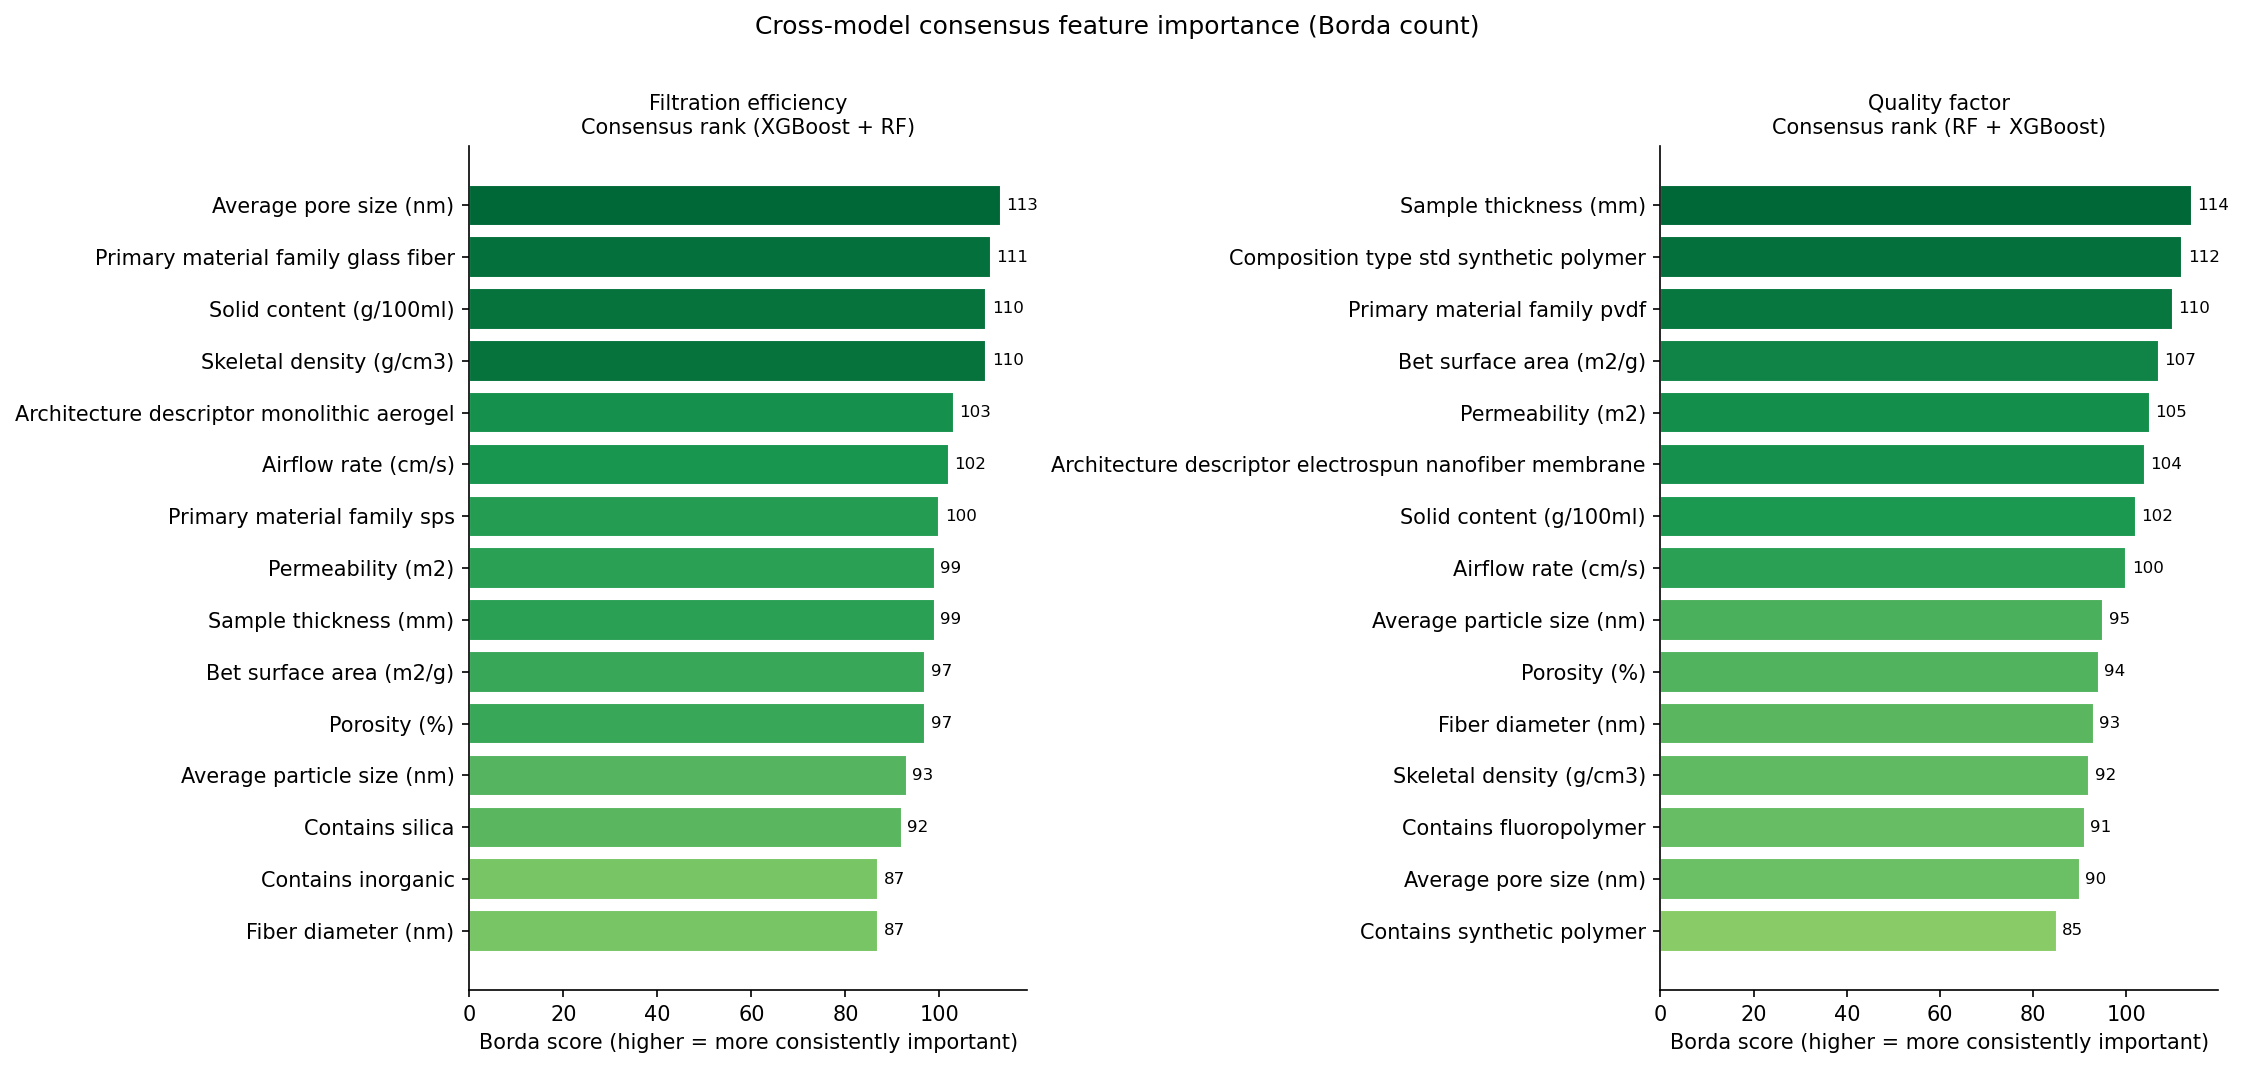

Saved: shap_consensus_ranking.png


In [16]:
# Visualize consensus rankings side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, consensus, title in [
    (axes[0], consensus_eff.head(15), 'Filtration efficiency\nConsensus rank (XGBoost + RF)'),
    (axes[1], consensus_qf.head(15),  'Quality factor\nConsensus rank (RF + XGBoost)'),
]:
    features  = consensus['Feature'].tolist()[::-1]
    scores    = consensus['Borda score'].tolist()[::-1]
    max_score = max(scores)
    colors    = plt.cm.RdYlGn([s / max_score for s in scores])

    bars = ax.barh(features, scores, color=colors, edgecolor='white')
    ax.set_xlabel('Borda score (higher = more consistently important)')
    ax.set_title(title, fontsize=10)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_width() + max_score * 0.01,
                bar.get_y() + bar.get_height()/2,
                str(int(val)), va='center', fontsize=8)

plt.suptitle('Cross-model consensus feature importance (Borda count)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('shap_consensus_ranking.png', bbox_inches='tight')
plt.show()
print('Saved: shap_consensus_ranking.png')

## 5.11: SHAP waterfall: individual sample explanations

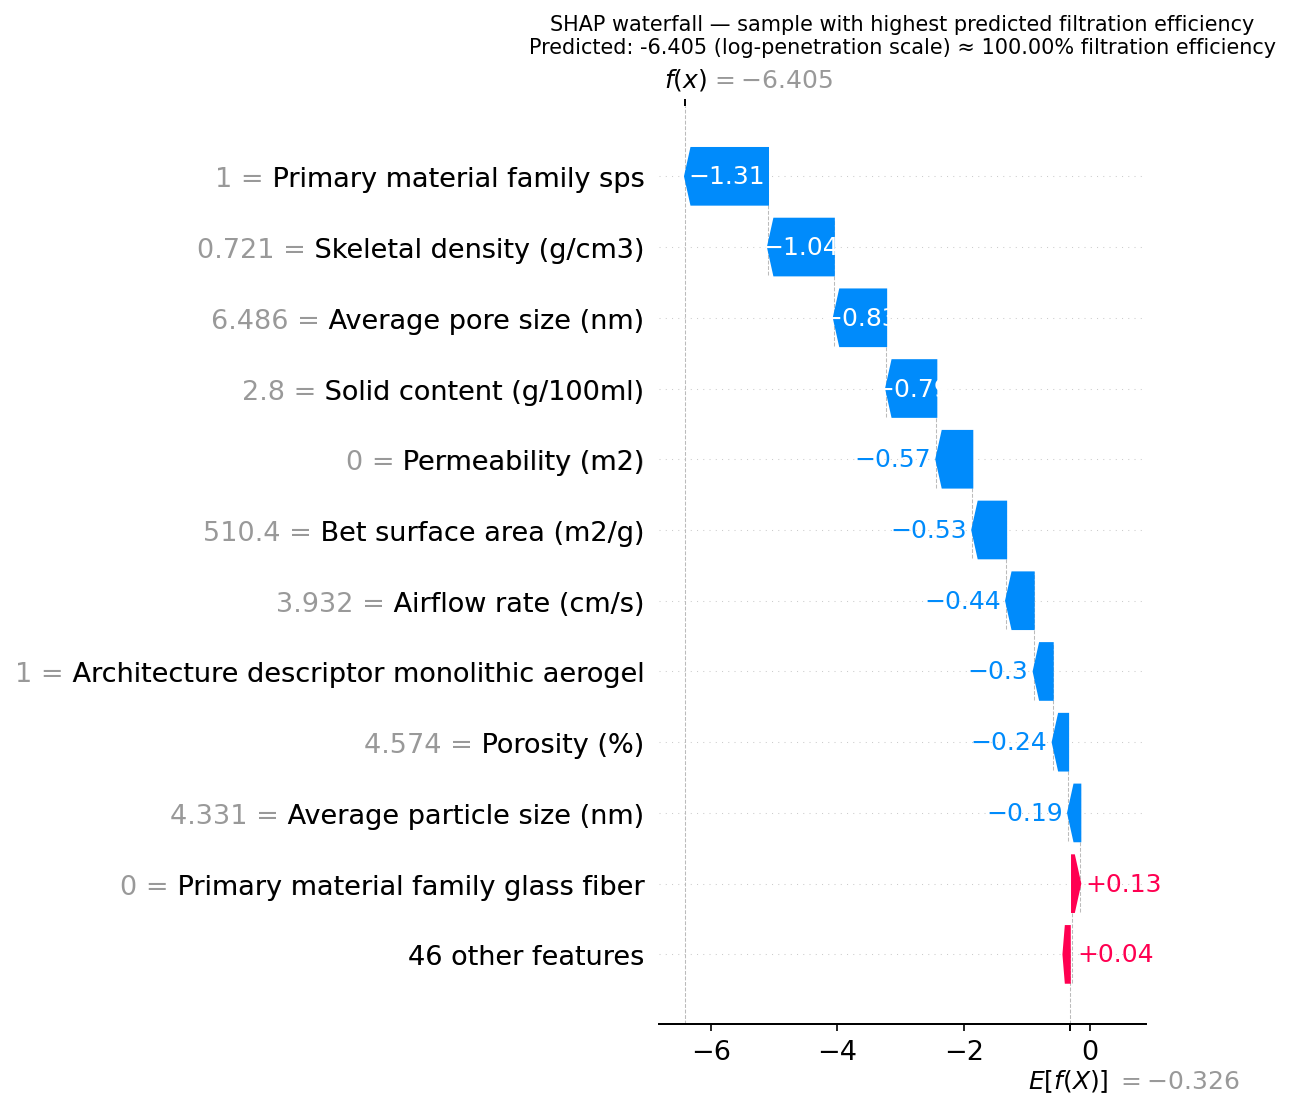

Saved: shap_waterfall_highest.png
  log-penetration = -6.405  →  filtration efficiency ≈ 100.00%


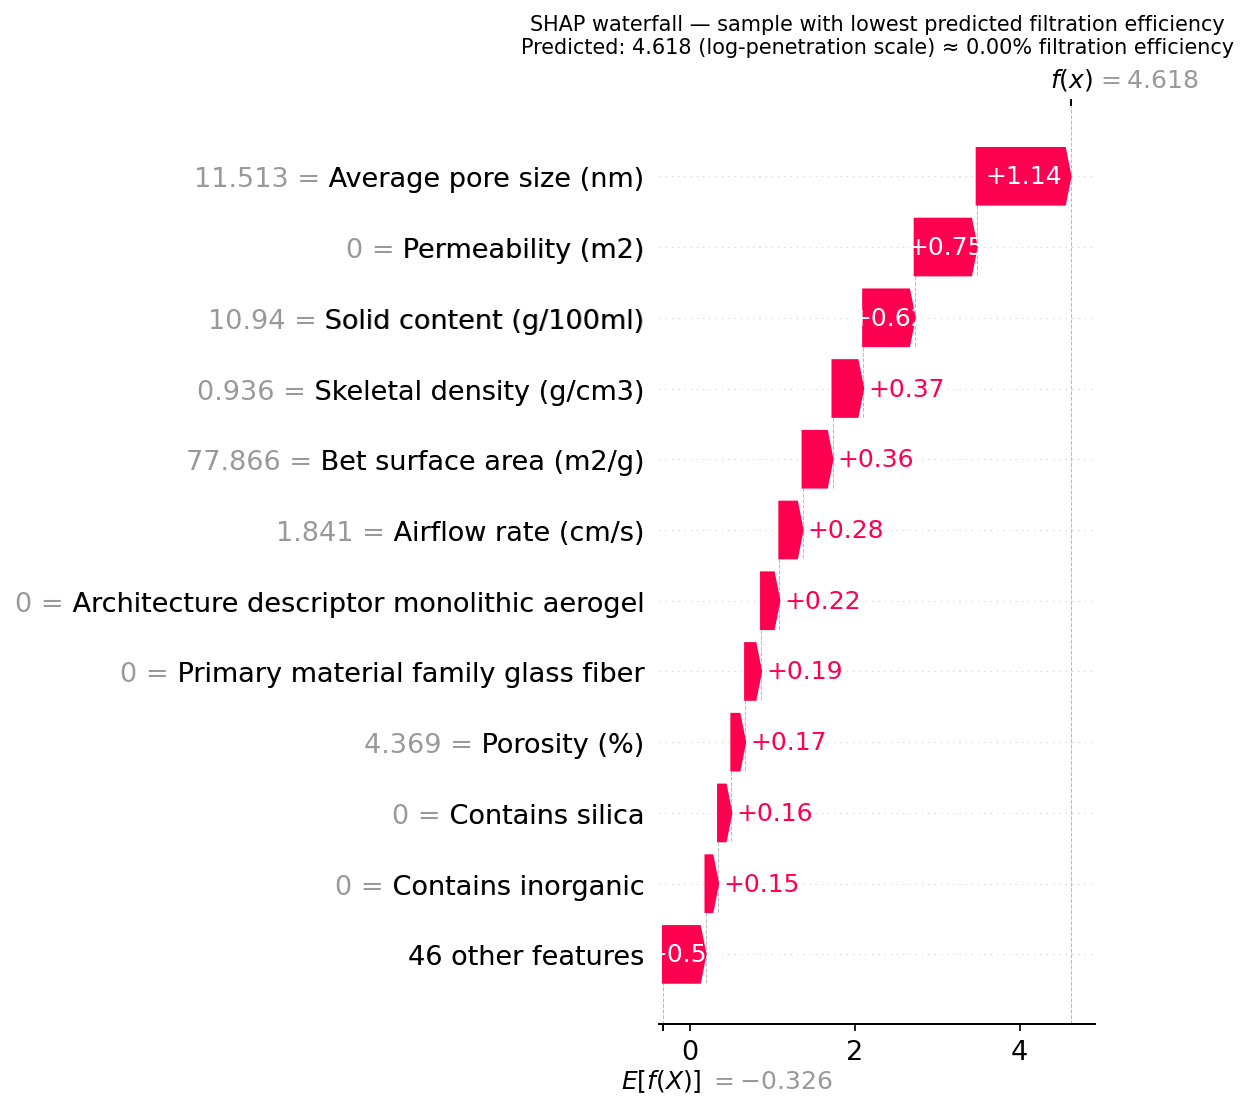

Saved: shap_waterfall_lowest.png
  log-penetration = 4.618  →  filtration efficiency ≈ 0.00%


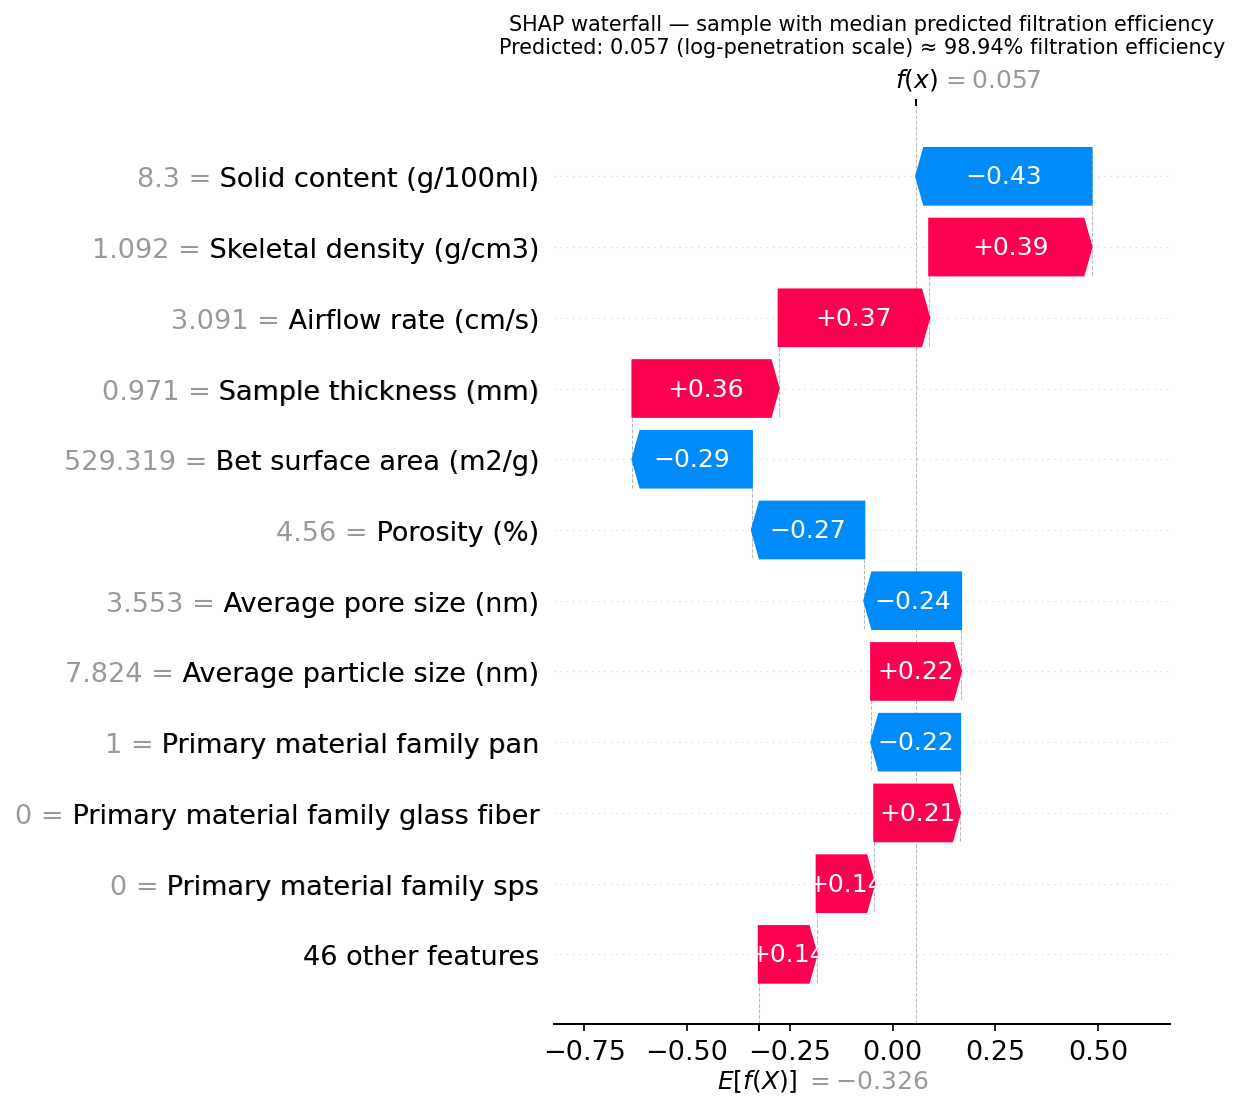

Saved: shap_waterfall_median.png
  log-penetration = 0.057  →  filtration efficiency ≈ 98.94%


In [17]:
preds_eff = final_xgb_eff.predict(X_eff_df.values)

# log-penetration is INVERTED relative to efficiency:
# most negative log-penetration = highest filtration efficiency
# most positive log-penetration = lowest filtration efficiency
idx_high   = np.argmin(preds_eff)   # most negative = highest efficiency
idx_low    = np.argmax(preds_eff)   # most positive = lowest efficiency
idx_median = np.argsort(preds_eff)[len(preds_eff)//2]

explainer_xgb_eff_new = shap.Explainer(final_xgb_eff, X_eff_df)
shap_values_new = explainer_xgb_eff_new(X_eff_df)

for idx, label in [
    (idx_high,   'highest predicted filtration efficiency'),
    (idx_low,    'lowest predicted filtration efficiency'),
    (idx_median, 'median predicted filtration efficiency'),
]:
    log_pen = preds_eff[idx]
    eff_pct = 100 - np.exp(log_pen)
    eff_pct = np.clip(eff_pct, 0, 100)

    fig, ax = plt.subplots(figsize=(10, 5))
    shap.plots.waterfall(shap_values_new[idx], max_display=12, show=False)
    plt.title(
        f'SHAP waterfall — sample with {label}\n'
        f'Predicted: {log_pen:.3f} (log-penetration scale) '
        f'≈ {eff_pct:.2f}% filtration efficiency',
        fontsize=10
    )
    plt.tight_layout()
    fname = f'shap_waterfall_{label.split()[0]}.png'
    plt.savefig(fname, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    print(f'  log-penetration = {log_pen:.3f}  →  filtration efficiency ≈ {eff_pct:.2f}%')

## 5.12: Save all SHAP values for record

In [18]:

shap_output = {
    'shap_xgb_eff':         shap_xgb_eff,
    'shap_rf_eff':           shap_rf_eff,
    'shap_rf_qf':            shap_rf_qf,
    'shap_xgb_qf':           shap_xgb_qf,
    'shap_interaction_eff':  shap_interaction_eff,
    'feature_names_eff':     feature_names_eff,
    'feature_names_qf':      feature_names_qf,
}

with open('step5_shap_values.pkl', 'wb') as f:
    pickle.dump(shap_output, f)

print('Files saved in this step:')
print('  step5_shap_values.pkl           — all raw SHAP arrays')
print('  shap_beeswarm.png               — primary importance figure')
print('  shap_bar.png                    — bar chart importance')
print('  shap_dependence_filtration.png  — dependence plots')
print('  shap_dependence_qualityfactor.png')
print('  shap_interaction_heatmap.png    — pairwise interactions')
print('  shap_consensus_ranking.png      — cross-model consensus')
print('  shap_waterfall_*.png            — individual explanations')
print('  shap_importance_all.csv         — numerical importance values')
print('  shap_interactions_filtration.csv')
print('  shap_consensus_filtration.csv')
print('  shap_consensus_qualityfactor.csv')
print()
print('Next: Step 6 — Bootstrap stability, subgroup analysis, design map')

Files saved in this step:
  step5_shap_values.pkl           — all raw SHAP arrays
  shap_beeswarm.png               — primary importance figure
  shap_bar.png                    — bar chart importance
  shap_dependence_filtration.png  — dependence plots
  shap_dependence_qualityfactor.png
  shap_interaction_heatmap.png    — pairwise interactions
  shap_consensus_ranking.png      — cross-model consensus
  shap_waterfall_*.png            — individual explanations
  shap_importance_all.csv         — numerical importance values
  shap_interactions_filtration.csv
  shap_consensus_filtration.csv
  shap_consensus_qualityfactor.csv

Next: Step 6 — Bootstrap stability, subgroup analysis, design map
